# House Price Prediction — Regression with Supervised Learning

## PART:-1 Problem Framing & Theory Notes

### Project Overview
The objective of this project is to build a supervised machine learning regression model that can predict house sale prices using different numerical and categorical features of a house.

The Ames Housing Dataset is used for this project. The target variable is `SalePrice`, which represents the selling price of a house.

Multiple regression algorithms such as Linear Regression, Ridge Regression, Lasso Regression, Random Forest Regressor, and XGBoost Regressor will be trained and evaluated to identify the best-performing model.

### 1. What is Regression? How is it different from Classification?

- Regression is a supervised machine learning technique used to predict continuous numerical values, such as house prices, salaries, or sales.
- Classification is used to predict discrete categories or classes, such as Yes/No, Fraud/Not Fraud, or Approved/Rejected.
- Example of Regression: Predicting the monthly EMI amount for a customer at HDFC Bank.
- Example of Regression: Predicting crop yield in Maharashtra based on rainfall, temperature, and soil conditions.

### 2. Difference between Simple Linear Regression, Multiple Linear Regression, and Regularised Regression

- Simple Linear Regression uses one independent variable to predict a continuous target variable.
- Multiple Linear Regression uses two or more independent variables to predict a continuous target variable.
- Ridge Regression uses L2 regularisation, which reduces large coefficients and helps control overfitting.
- Lasso Regression uses L1 regularisation, which can shrink some coefficients to exactly zero and perform feature selection.

### 3. Overfitting and Underfitting

- Overfitting occurs when a model learns the training data too closely, including noise, and performs poorly on unseen test data.
- Underfitting occurs when a model is too simple to capture important patterns in the data and performs poorly on both training and test data.
- L1 regularisation (Lasso) adds a penalty based on the absolute values of model coefficients and can reduce some coefficients to zero.
- L2 regularisation (Ridge) adds a penalty based on the squared values of coefficients and reduces large coefficients, helping to prevent overfitting.

### 4. RMSE, MAE, and R²

- MAE (Mean Absolute Error) calculates the average absolute difference between actual and predicted values.
- RMSE (Root Mean Squared Error) measures prediction error but gives a larger penalty to large errors.
- R² Score represents how much variance in the target variable is explained by the model. A value closer to 1 generally indicates better performance.
- RMSE is preferred over MAE when large prediction errors are more costly and should receive a higher penalty.


### 5. What is Cross-Validation (k-Fold)?

- K-Fold Cross-Validation divides the dataset into K equal parts or folds.
- The model is trained on K-1 folds and validated on the remaining fold, repeating the process K times.
- It provides a more reliable estimate of model performance because every data point gets a chance to be part of the validation set.
- It is preferred over a single train-test split because the evaluation is less dependent on one particular random split of the dataset.

## PART:-2 Import Required Libraries

In [84]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats
from scipy.stats import skew

# Q-Q Plot
import statsmodels.api as sm

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)

In [85]:
# Load Dataset

df = pd.read_csv(r"C:\Users\HP\Downloads\house-prices-advanced-regression-techniques\train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [86]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Interpretation

The dataset has been loaded successfully into a Pandas DataFrame. Displaying the first five rows helps understand the structure, feature names, and target variable before performing exploratory data analysis.

In [87]:
# Dataset Shape

print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (1460, 81)
Number of Rows: 1460
Number of Columns: 81


### Interpretation

The shape shows the total number of rows and columns present in the dataset.

## Dataset Information

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Interpretation

The information shows the data type of each feature, number of non-null values, and memory usage. It also helps identify missing values.

## Statistical Summary

In [89]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Interpretation

The statistical summary provides important information such as mean, standard deviation, minimum, maximum, and quartile values for numerical features.

## Separate Numerical and Categorical Features

In [90]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include="object").columns

print("Number of Numerical Columns :", len(num_cols))

print("Number of Categorical Columns :", len(cat_cols))

Number of Numerical Columns : 38
Number of Categorical Columns : 43


### Interpretation

Separating numerical and categorical columns makes preprocessing and visualization easier.

## Check Missing Values in numirical columns

In [91]:
df[num_cols].isnull().sum()

Id                 0
MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

### Interpretation

This analysis identifies features containing missing values. These missing values will be handled during the preprocessing step.

## Check Missing Values in categorical columns

In [92]:
df[cat_cols].isnull().sum()

MSZoning            0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinType2       38
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
KitchenQual         0
Functional          0
FireplaceQu       690
GarageType         81
GarageFinish       81
GarageQual         81
GarageCond         81
PavedDrive          0
PoolQC           1453
Fence            1179
MiscFeature      1406
SaleType            0
SaleCondition       0
dtype: int64

### Interpretation

This analysis identifies features containing missing values. These missing values will be handled during the preprocessing step.

## Missing Value Percentage

In [93]:
(df.isnull().sum()/len(df))*100


Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

### Interpretation

The percentage of missing values helps determine whether a feature should be imputed or removed.

##  Distribution of Target Variable (SalePrice)

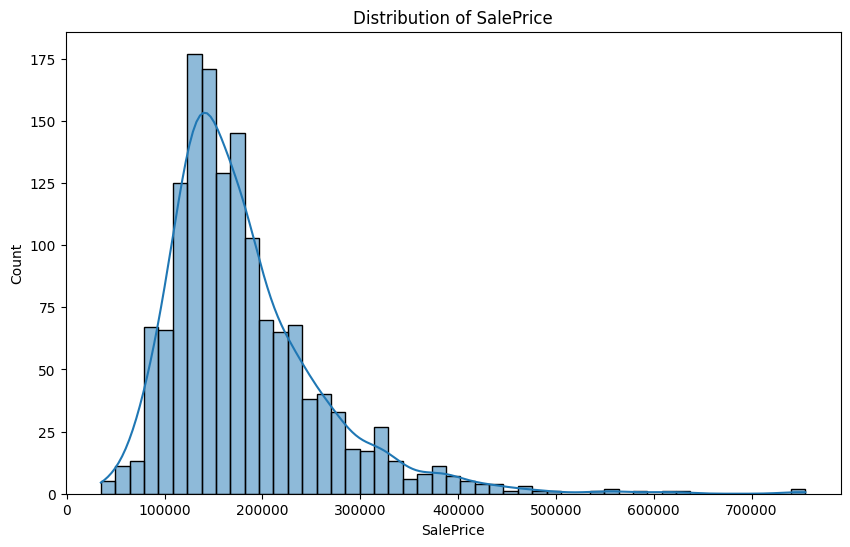

In [94]:
plt.figure(figsize=(10,6))
sns.histplot(df["SalePrice"],kde = True)
plt.title("Distribution of SalePrice")
plt.show()

### Interpretation

The histogram shows the distribution of the target variable. A positively skewed distribution indicates that transformation may improve model performance.

## Q-Q Plot of SalePrice

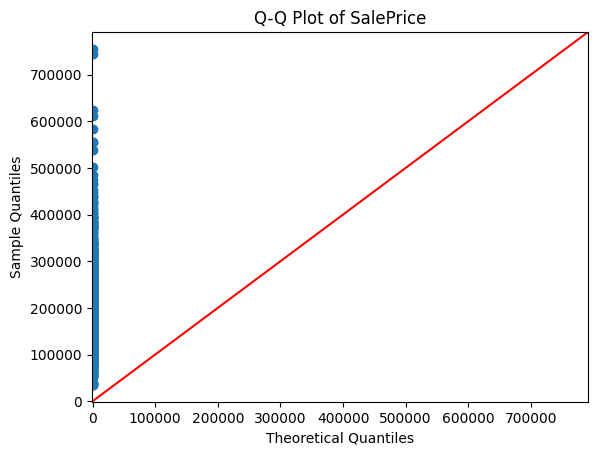

In [95]:
sm.qqplot(df["SalePrice"], line="45")

plt.title("Q-Q Plot of SalePrice")

plt.show()

### Interpretation

The Q-Q plot compares the target variable with a normal distribution. Large deviations from the reference line indicate non-normality.

## Apply Log Transformation

In [96]:
df["SalePrice"] = np.log1p(df["SalePrice"])

### Interpretation

Log transformation reduces skewness and makes the target variable closer to a normal distribution, improving regression model performance.

## Distribution After Log Transformation

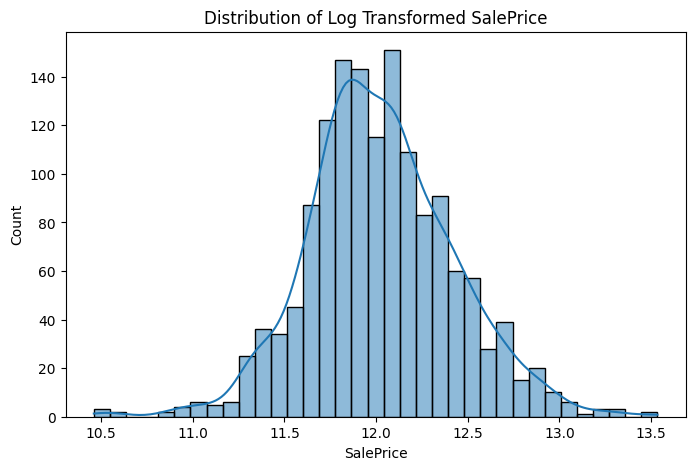

In [97]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of Log Transformed SalePrice")

plt.show()

## Q-Q Plot After Log Transformation

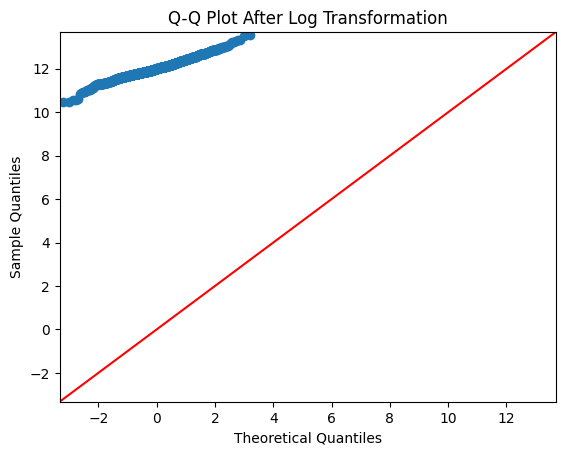

In [98]:
sm.qqplot(df["SalePrice"], line="45")

plt.title("Q-Q Plot After Log Transformation")

plt.show()

### Interpretation

After applying the logarithmic transformation, the target variable becomes more normally distributed, which is beneficial for linear regression models.

# Univariate Analysis

## Distribution of Numerical Features

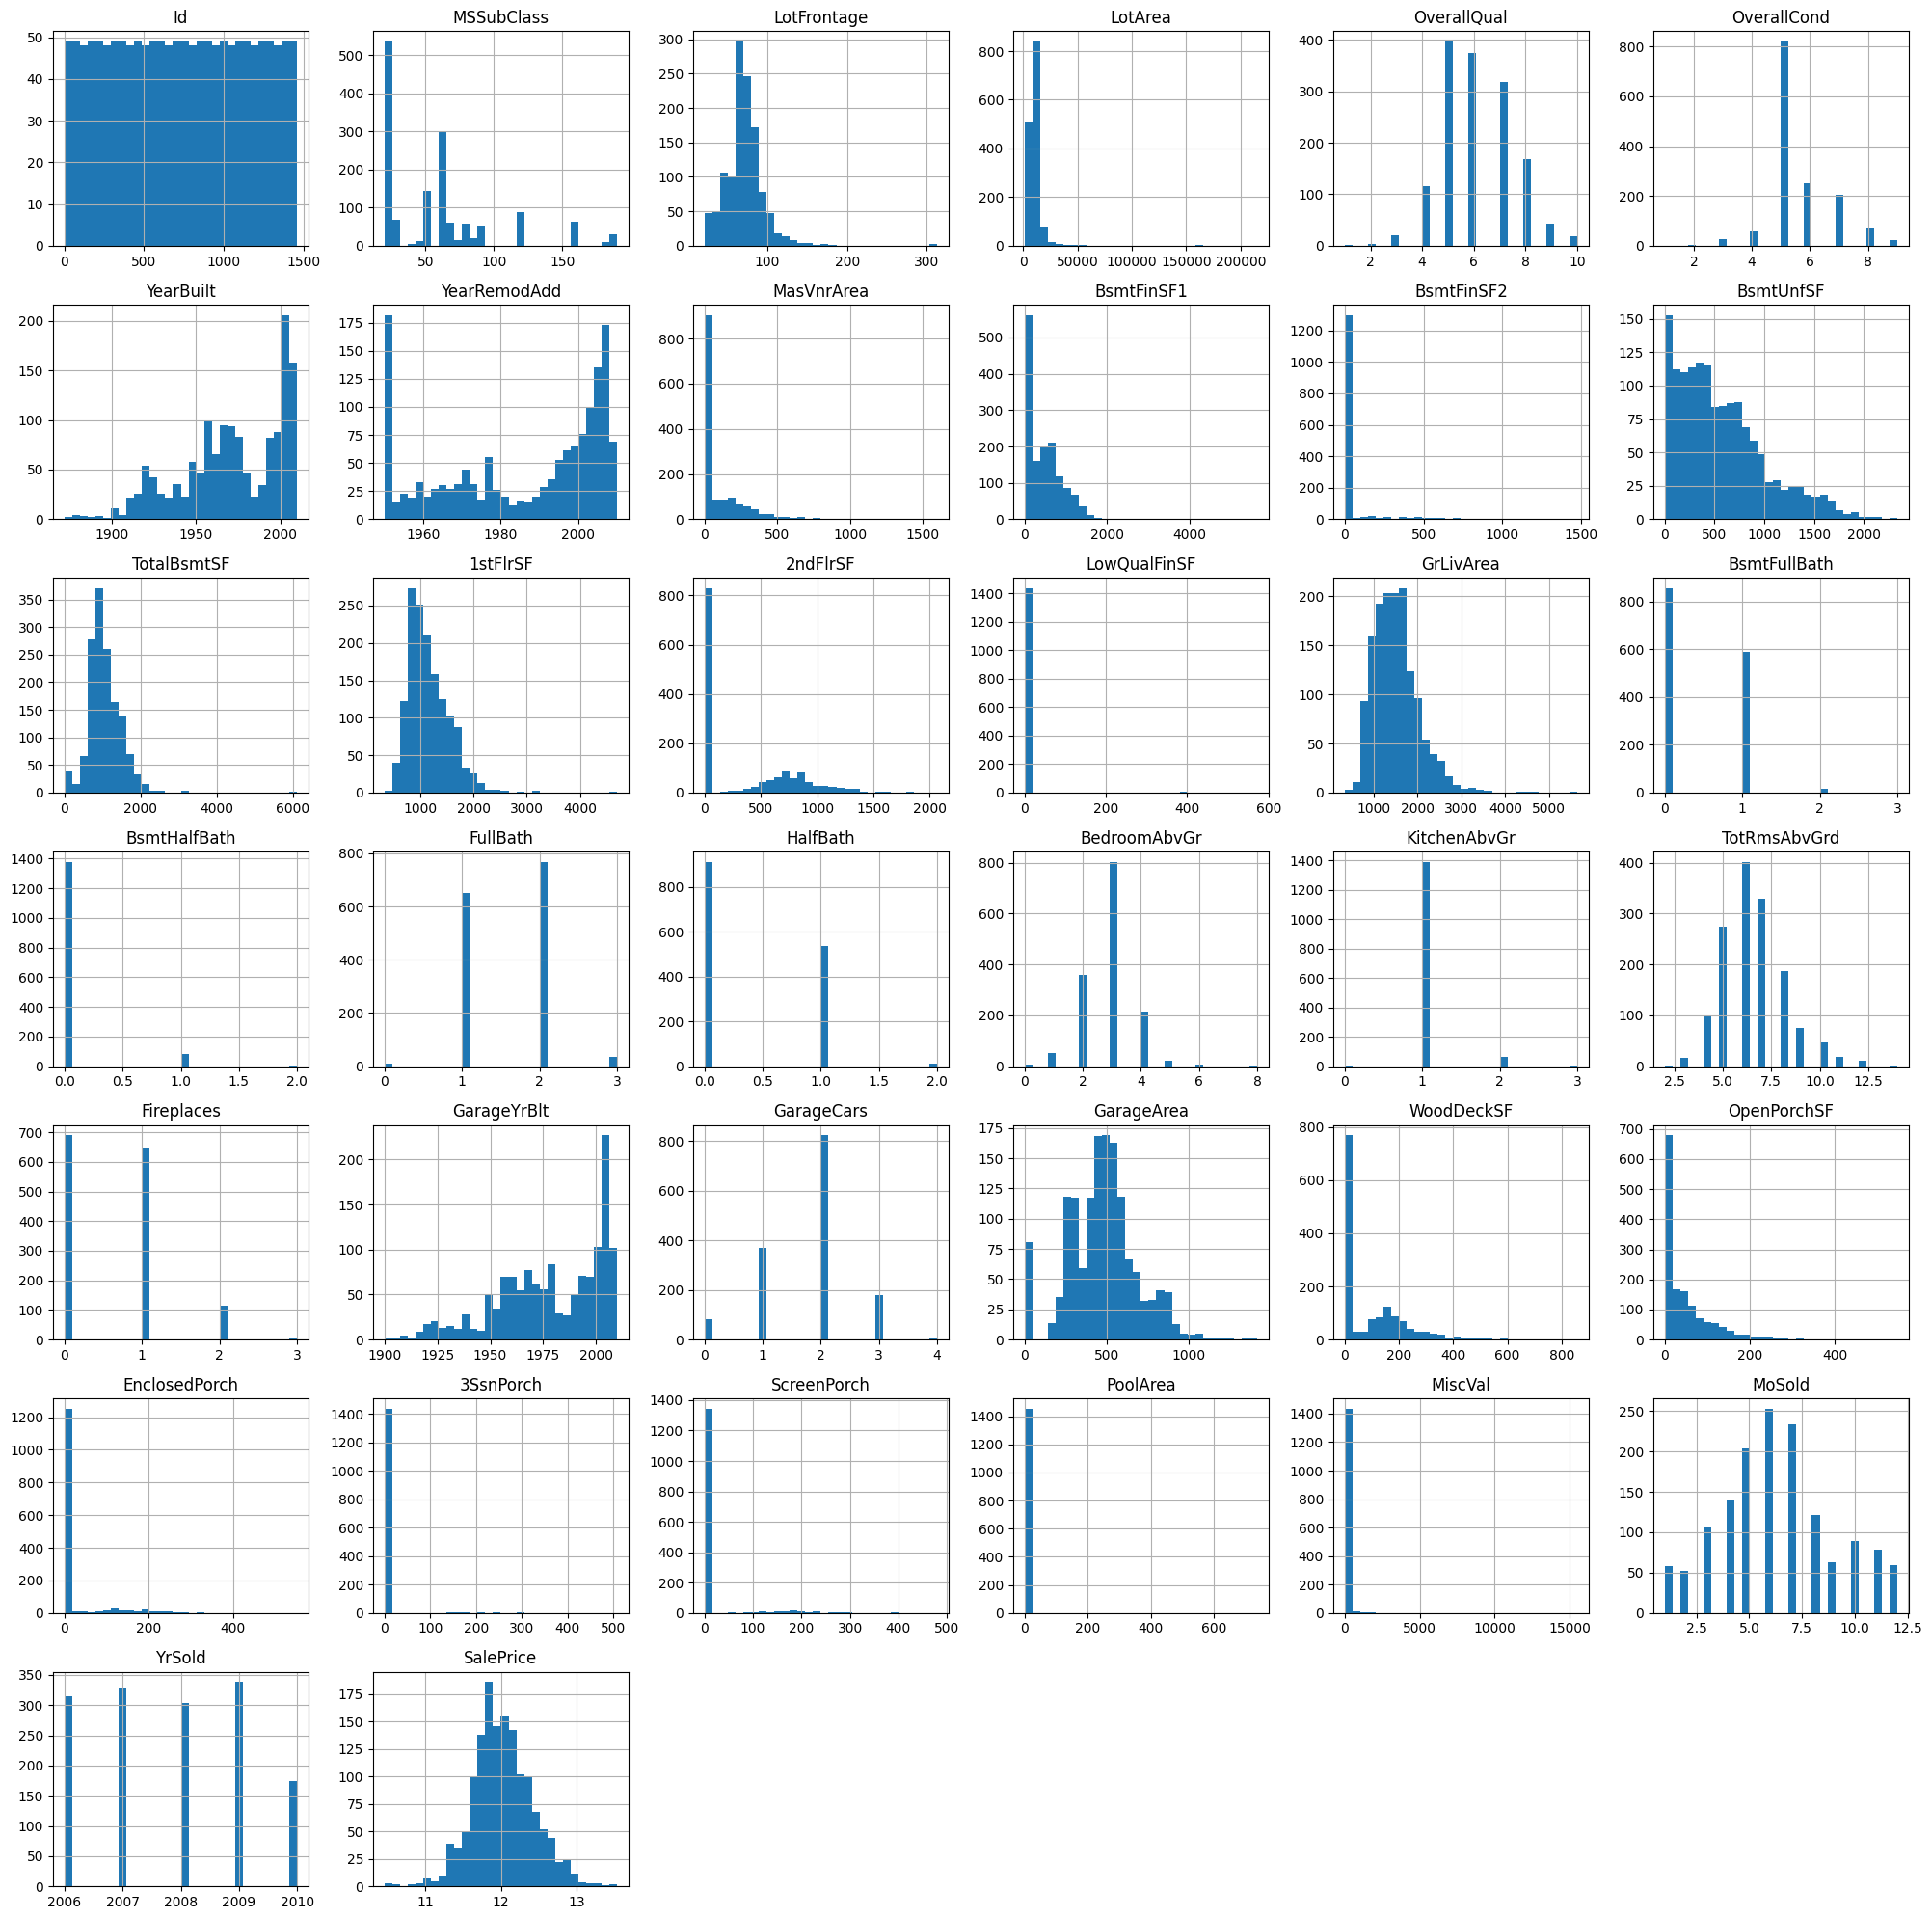

In [99]:
df[num_cols].hist(figsize=(20,20), bins=30)

plt.tight_layout()

plt.show()

### Interpretation

The histograms show the distribution of all numerical features. This helps identify skewness, normality, and unusual data patterns before preprocessing.

## Find Top 5 Skewed Features

In [100]:
skewness = df[num_cols].apply(lambda x: skew(x.dropna()))

skewness = skewness.sort_values(ascending=False)

skewness.head(5)

MiscVal         24.451640
PoolArea        14.813135
LotArea         12.195142
3SsnPorch       10.293752
LowQualFinSF     9.002080
dtype: float64

### Interpretation

The output shows the five most positively skewed numerical features. Highly skewed features often require transformation before model training.

## Count Plot of Neighborhood

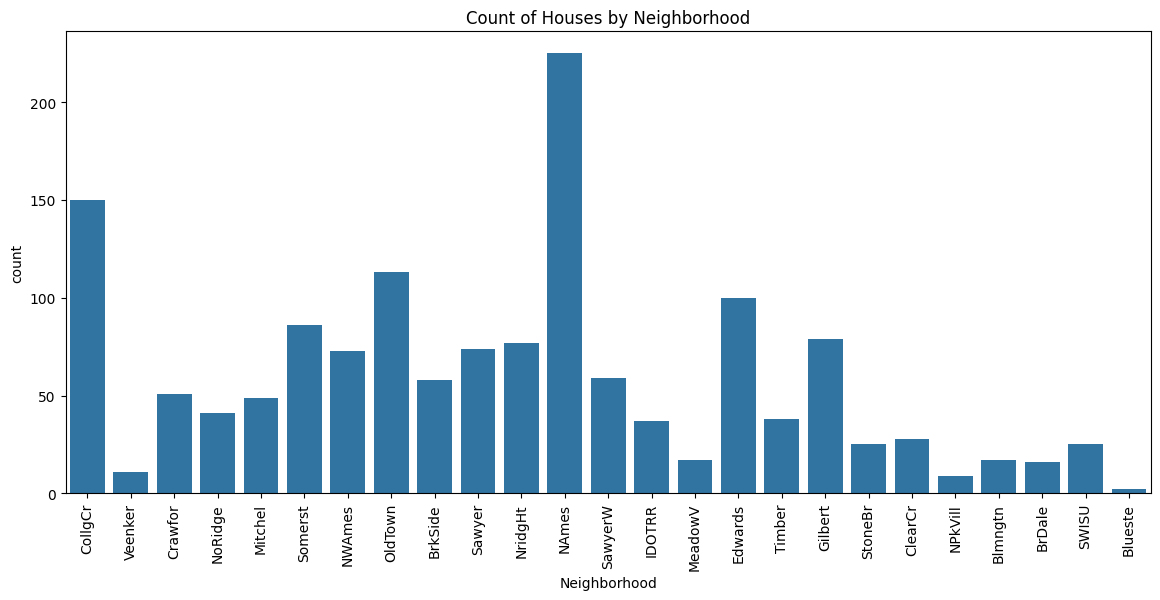

In [101]:
plt.figure(figsize=(14,6))

sns.countplot(data=df, x="Neighborhood")

plt.xticks(rotation=90)

plt.title("Count of Houses by Neighborhood")

plt.show()

### Interpretation

The count plot shows the number of houses available in each neighborhood. Some neighborhoods contain significantly more houses than others.

## Count Plot of Building Type

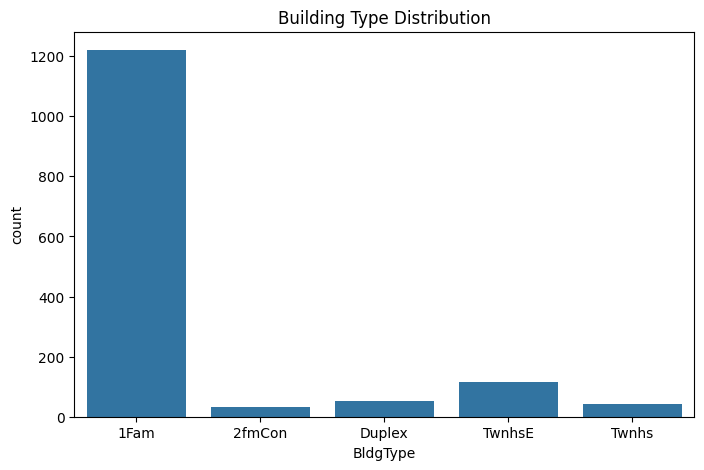

In [102]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="BldgType")

plt.title("Building Type Distribution")

plt.show()

### Interpretation

This visualization shows the distribution of different building types within the dataset.

## Count Plot of House Style

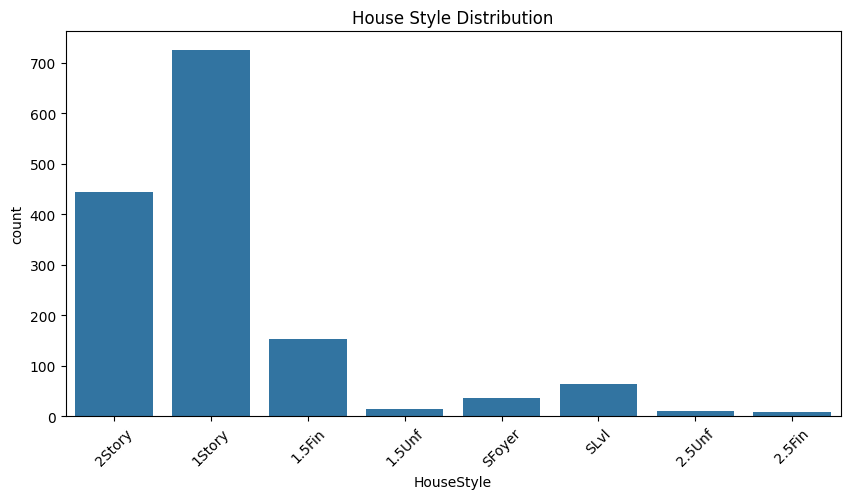

In [103]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="HouseStyle")

plt.xticks(rotation=45)

plt.title("House Style Distribution")

plt.show()

### Interpretation

The plot displays the frequency of different house styles and helps understand the dataset composition.

# Bivariate Analysis

## Correlation Heatmap

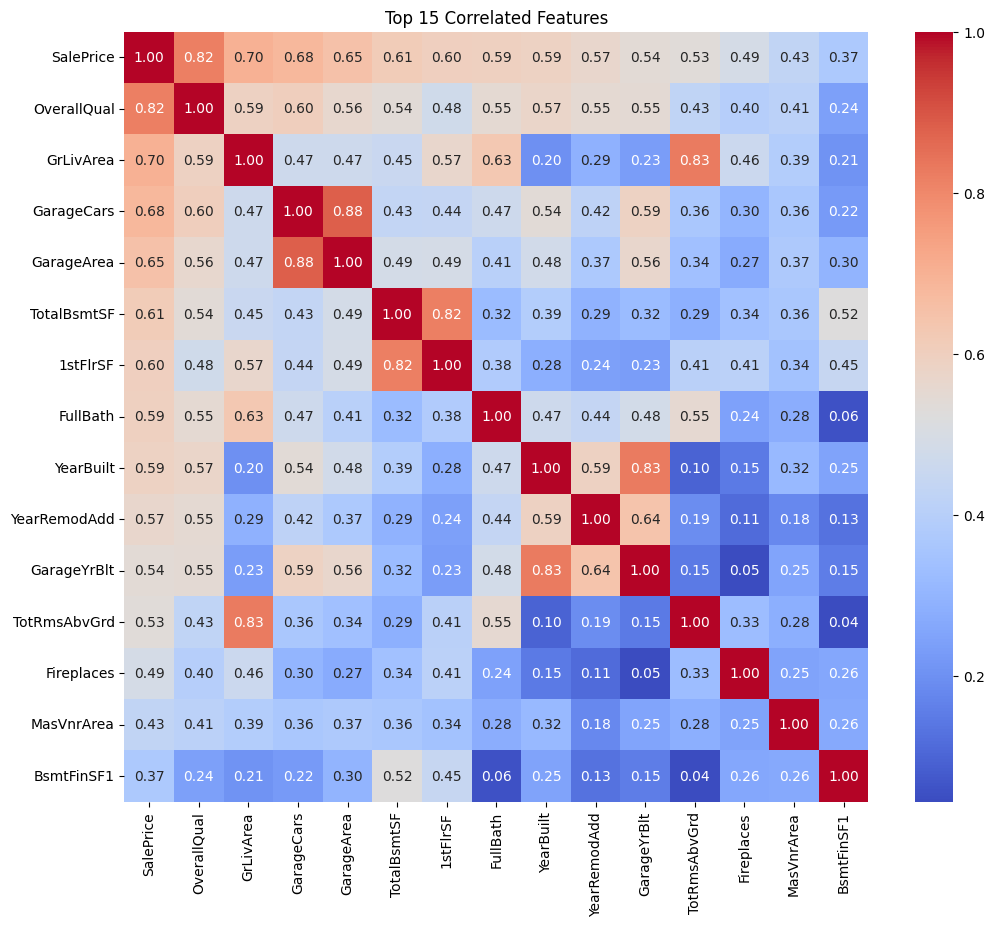

In [104]:
corr = df.corr(numeric_only=True)

top_corr = corr["SalePrice"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,10))

sns.heatmap(df[top_corr].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Top 15 Correlated Features")

plt.show()

### Interpretation

The heatmap highlights the strongest relationships between numerical variables and the target variable. Highly correlated features are useful for prediction.

## Scatter Plot: GrLivArea vs SalePrice

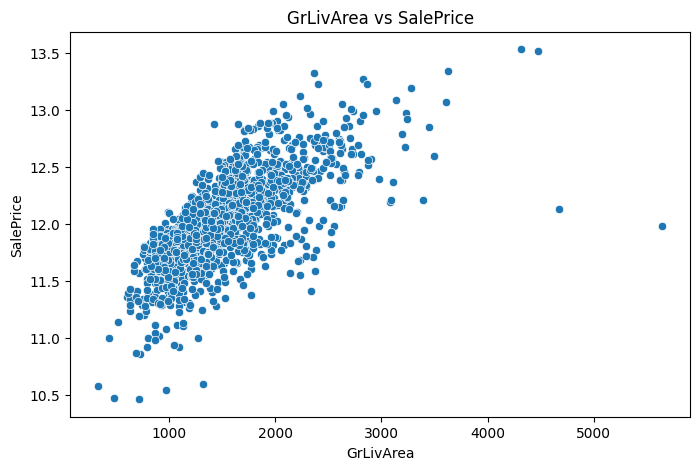

In [105]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")

plt.title("GrLivArea vs SalePrice")

plt.show()

### Interpretation

The scatter plot shows that larger living area generally leads to higher house prices, indicating a positive relationship.

## Scatter Plot: GarageArea vs SalePrice

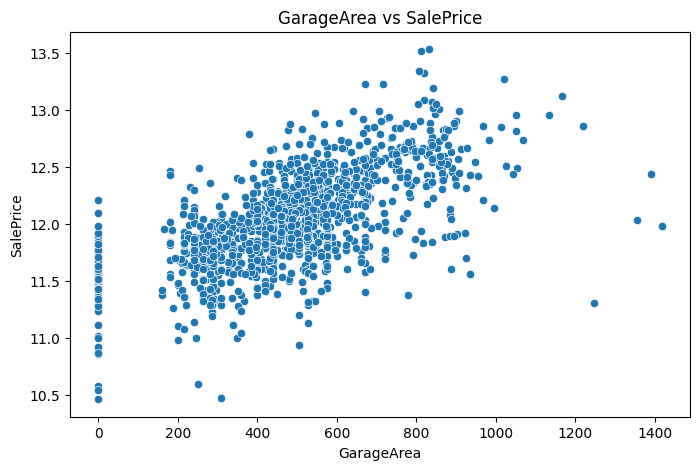

In [106]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="GarageArea", y="SalePrice")

plt.title("GarageArea vs SalePrice")

plt.show()

### Interpretation

Houses with larger garage areas generally have higher sale prices, although a few outliers are present.

## Scatter Plot: TotalBsmtSF vs SalePrice

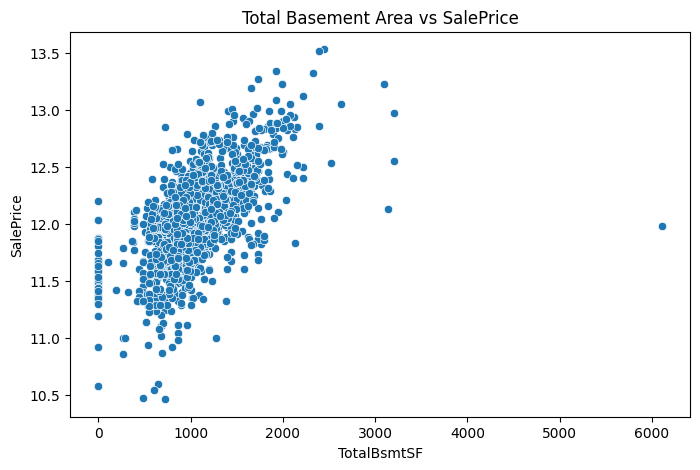

In [107]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="TotalBsmtSF", y="SalePrice")

plt.title("Total Basement Area vs SalePrice")

plt.show()

### Interpretation

The basement area has a positive relationship with house price. Larger basement sizes generally correspond to higher prices.

## Box Plot: Overall Quality vs SalePrice

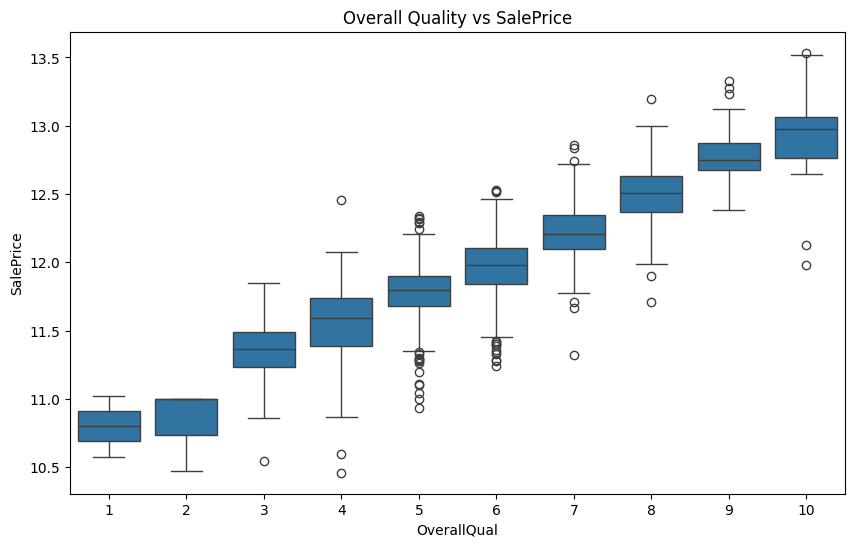

In [108]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="OverallQual", y="SalePrice")

plt.title("Overall Quality vs SalePrice")

plt.show()

### Interpretation

Higher overall quality ratings are associated with higher house prices. The box plot also reveals price variability within each quality level.

## Box Plot: Neighborhood vs SalePrice

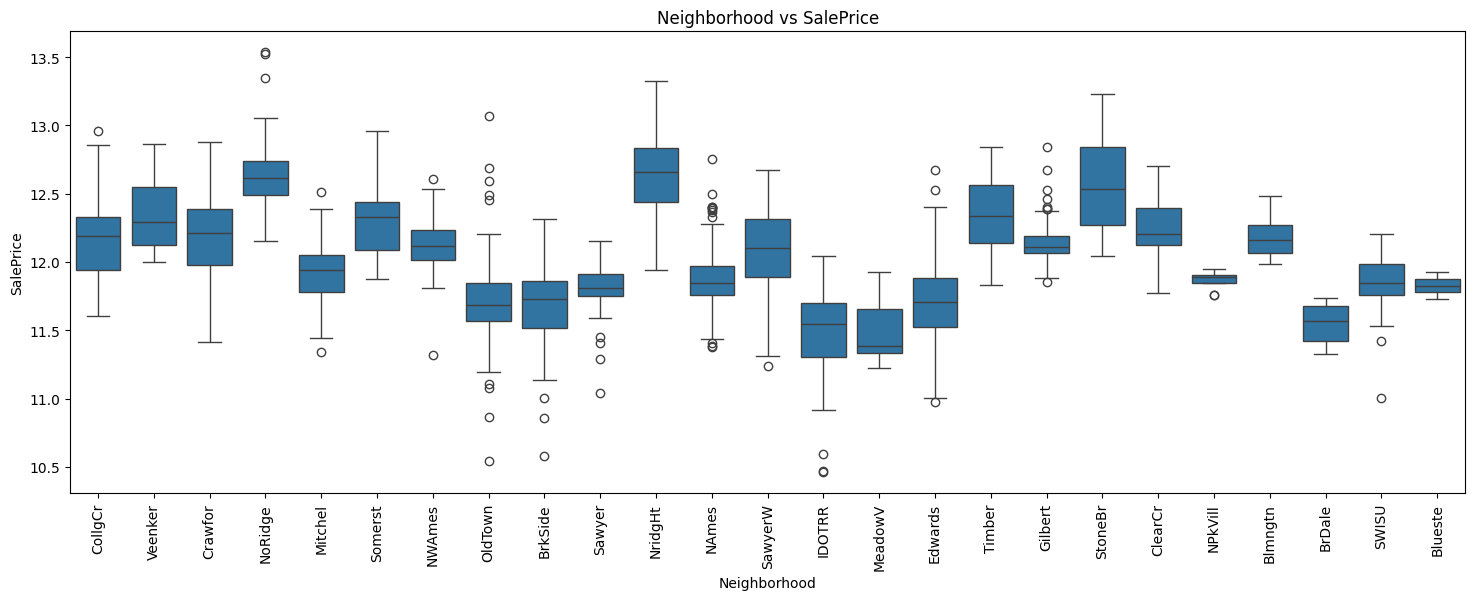

In [109]:
plt.figure(figsize=(18,6))

sns.boxplot(data=df, x="Neighborhood", y="SalePrice")

plt.xticks(rotation=90)

plt.title("Neighborhood vs SalePrice")

plt.show()

### Interpretation

The box plot compares house prices across different neighborhoods, showing that some neighborhoods consistently have higher median prices.

## Detect Outliers using IQR

In [110]:
Q1 = df["SalePrice"].quantile(0.25)

Q3 = df["SalePrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[(df["SalePrice"] < lower) | (df["SalePrice"] > upper)]

print("Number of Outliers :", outliers.shape[0])

Number of Outliers : 28


### Interpretation

The IQR method identifies unusually low or high house prices. These observations may influence model performance and can be handled during preprocessing if necessary.

# Conclusion

**In this step, the Ames Housing dataset was loaded and explored using Exploratory Data Analysis (EDA). The dataset structure, feature types, missing values, target variable distribution, feature relationships, and potential outliers were analyzed. These insights provide a clear understanding of the data and prepare it for preprocessing and regression model development.**

## PART:-3 Data Preprocessing & Feature Engineering


## Handle Missing Values
## Objective

**The objective of this section is to identify and handle missing values appropriately so that the machine learning model can learn from complete and meaningful data without errors.**

## Report Missing Values

In [111]:
# Count missing values in each column
missing_values = df.isnull().sum()

# Keep only columns having missing values
missing_values = missing_values[missing_values > 0]

# Calculate missing percentage
missing_percentage = (missing_values / len(df)) * 100

# Create a summary DataFrame
missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

# Sort in descending order
missing_report = missing_report.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_report

,Missing Values,Missing Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


### Interpretation

The above table shows all columns containing missing values along with their missing percentages. This helps us decide whether to fill or remove missing values in later preprocessing steps.

## Fill Categorical Missing Values with 'None'                

In [112]:
# Columns where NaN means the feature is not available
none_columns = [
    "PoolQC",
    "Fence",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "FireplaceQu",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "Alley",
    "MiscFeature",
    "MasVnrType"
]

# Fill missing values with 'None'
for col in none_columns:
    if col in df.columns:
        df[col] = df[col].fillna("None")

print("Categorical missing values filled with 'None'.")

Categorical missing values filled with 'None'.


## Why Fill with None?

For these columns, a missing value does not mean the data is unknown. It indicates that the feature does not exist (for example, no garage or no swimming pool). Therefore, replacing NaN with "None" preserves this information.

## Fill Numerical Missing Values with 0

In [113]:
# Numerical columns where NaN means feature is absent
zero_columns = [
    "GarageArea",
    "GarageCars",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]

# Fill missing values with 0
for col in zero_columns:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print("Numerical missing values filled with 0.")

Numerical missing values filled with 0.


### Why Fill with 0?

For these numerical features, a missing value usually indicates that the house does not have that facility (such as no basement or no garage). Therefore, replacing missing values with 0 correctly represents the absence of the feature.

## Fill Remaining Numerical Missing Values with Median

In [114]:
# Select all numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Fill remaining missing values with median, with a fallback for all-NaN columns
for col in numerical_columns:
    median_val = df[col].median()
    # If the median is NaN, it means the column is entirely NaN, so fill with 0
    if pd.isna(median_val):
        median_val = 0
    df[col] = df[col].fillna(median_val)

print("Remaining numerical missing values filled using median (with NaN fallback to 0).")

Remaining numerical missing values filled using median (with NaN fallback to 0).


### Why Median?

The median is less affected by extreme values (outliers) than the mean. Therefore, it is commonly used to fill missing numerical values in regression datasets.

## Drop Columns with More Than 80% Missing Values

In [115]:
# Calculate missing percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Columns having more than 80% missing values
drop_columns = missing_percentage[
    missing_percentage > 80
].index

print("Columns to Drop:")
print(drop_columns)

# Drop columns
df = df.drop(columns=drop_columns)

print("\nRemaining Shape:", df.shape)

Columns to Drop:
Index([], dtype='object')

Remaining Shape: (1460, 81)


### Why Drop These Columns?

Columns with more than 80% missing values contain very little useful information. Keeping them may introduce noise and reduce the model's performance, so they are removed.

## Outlier Removal

### Objective

The objective of this step is to identify and remove extreme outliers from the dataset. Removing outliers helps improve the performance of regression models by reducing the influence of abnormal observations.

## Visualize Outliers

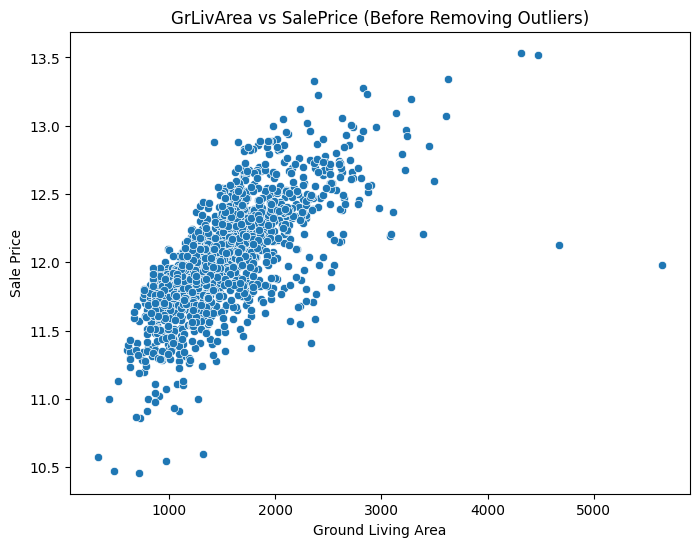

In [116]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("GrLivArea vs SalePrice (Before Removing Outliers)")
plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

### Interpretation

The scatter plot helps visualize the relationship between Ground Living Area and Sale Price. Two houses have an unusually large living area but relatively low sale prices. These observations are considered extreme outliers.

## Identify Outliers

In [117]:
outliers = df[
    (df["GrLivArea"] > 4000) &
    (np.expm1(df["SalePrice"]) < 300000)
]

print("Number of Outliers :", outliers.shape[0])

outliers[["GrLivArea", "SalePrice"]]

Number of Outliers : 2


,GrLivArea,SalePrice
523,4676,12.126764
1298,5642,11.982935


### Interpretation

The output displays the records that satisfy the outlier condition mentioned in the practical exam. These are the two observations that should be removed before model training.

## Remove Outliers

In [118]:
print("Dataset Shape Before Removing Outliers :", df.shape)

df = df.drop(outliers.index)

print("Dataset Shape After Removing Outliers :", df.shape)

Dataset Shape Before Removing Outliers : (1460, 81)
Dataset Shape After Removing Outliers : (1458, 81)


### Interpretation

The identified outlier rows have been removed successfully. The updated dataset now contains only normal observations for model training.

## Why Removing These Outliers is Important?

- These houses have extremely large living areas but unusually low sale prices.
- Such observations do not represent the normal relationship between house size and price.
- Linear Regression tries to fit a single best-fit line, and these extreme points pull the regression line toward themselves.
- As a result, prediction accuracy decreases and model performance becomes poor.
- Removing these abnormal observations helps improve model generalization and prediction quality.

## Feature Engineering

### Objective

The objective of this step is to create new meaningful features from the existing dataset. These engineered features help the machine learning model capture hidden relationships and improve prediction accuracy.

## Create TotalSF Feature

In [119]:
# Total usable area of the house
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

# Display first 5 values
df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


### Why Create TotalSF?

Instead of using basement, first floor, and second floor separately, combining them into a single feature gives the total usable area of the house. This feature often has a stronger relationship with house price.

## Create HouseAge Feature

In [120]:
# Age of the house at the time of sale
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# Display first 5 values
df[["YrSold", "YearBuilt", "HouseAge"]].head()

,YrSold,YearBuilt,HouseAge
0,2008,2003,5
1,2007,1976,31
2,2008,2001,7
3,2006,1915,91
4,2008,2000,8


### Why Create HouseAge?

The age of a house is generally more useful than the construction year. Older houses may have lower market value compared to newer houses.

## Create RemodAge Feature

In [121]:
# Years since last remodeling
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

# Display first 5 values
df[["YrSold", "YearRemodAdd", "RemodAge"]].head()

,YrSold,YearRemodAdd,RemodAge
0,2008,2003,5
1,2007,1976,31
2,2008,2002,6
3,2006,1970,36
4,2008,2000,8


### Why Create RemodAge?

A recently renovated house usually has a higher value than one that was renovated many years ago. This feature captures that information.

## Create HasGarage Feature

In [122]:
# 1 = Garage Available, 0 = No Garage
df["HasGarage"] = np.where(df["GarageArea"] > 0, 1, 0)

# Display first 5 values
df[["GarageArea", "HasGarage"]].head()

,GarageArea,HasGarage
0,548,1
1,460,1
2,608,1
3,642,1
4,836,1


### Why Create HasGarage?

Instead of using the garage area alone, a binary feature clearly indicates whether a house has a garage or not. This makes it easier for some machine learning algorithms to identify the importance of garage availability.

## Create HasPool Feature

In [123]:
# 1 = Swimming Pool Available, 0 = No Swimming Pool
df["HasPool"] = np.where(df["PoolArea"] > 0, 1, 0)

# Display first 5 values
df[["PoolArea", "HasPool"]].head()

,PoolArea,HasPool
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


### Why Create HasPool?

A swimming pool is an important property feature. A binary indicator simplifies this information by identifying whether the house has a pool or not.

## Verify Newly Created Features

In [124]:
new_features = [
    "TotalSF",
    "HouseAge",
    "RemodAge",
    "HasGarage",
    "HasPool"
]

df[new_features].head()

,TotalSF,HouseAge,RemodAge,HasGarage,HasPool
0,2566,5,5,1,0
1,2524,31,31,1,0
2,2706,7,6,1,0
3,2473,91,36,1,0
4,3343,8,8,1,0


## Conclusion

In this step, five new features were created from the existing dataset: **TotalSF**, **HouseAge**, **RemodAge**, **HasGarage**, and **HasPool**. These engineered features capture meaningful property characteristics that are not directly available in the original dataset. As a result, they can improve the learning capability and prediction accuracy of regression models.

## Encoding & Scaling

## Encoding

### Objective

The objective of this step is to convert categorical variables into numerical format so that machine learning algorithms can process them correctly. Different encoding techniques are applied based on the nature of the categorical features.

In [125]:
quality_mapping = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

ordinal_columns = [
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "FireplaceQu"
]

for col in ordinal_columns:
    if col in df.columns:
        df[col] = df[col].map(quality_mapping)


from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

if "Neighborhood" in df.columns:
    df["Neighborhood"] = label_encoder.fit_transform(df["Neighborhood"])

# Identify all remaining object columns after ordinal and label encoding
# This dynamically captures any categorical columns that haven't been handled yet.
remaining_object_columns = df.select_dtypes(include='object').columns

# Debug print: What are the object columns before one-hot encoding?
print(f"Object columns BEFORE one-hot encoding: {list(remaining_object_columns)}")

# Apply one-hot encoding to all identified remaining object columns
# This ensures that MSZoning and any other unprocessed categorical columns are handled.
if len(remaining_object_columns) > 0:
    df = pd.get_dummies(df, columns=remaining_object_columns, drop_first=True, dtype=int)

# Double-check for any object columns that might have slipped through and forcefully drop them
final_object_columns = df.select_dtypes(include='object').columns
if len(final_object_columns) > 0:
    print(f"WARNING: Remaining object columns AFTER one-hot encoding: {list(final_object_columns)}")
    # Forcefully drop these columns to proceed with model training
    df = df.drop(columns=final_object_columns)
    print("Forcefully dropped remaining object columns.")


print("Encoding Completed Successfully!")

Object columns BEFORE one-hot encoding: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Encoding Completed Successfully!


### Interpretation

- Ordinal Encoding was applied to quality-related features while preserving their natural order.
- One-Hot Encoding converted nominal categorical variables into binary columns.
- Label Encoding was applied to the high-cardinality column **Neighborhood**.
- The dataset now contains numerical representations of categorical features and is ready for further preprocessing.

## Conclusion

**Categorical variables were successfully converted into numerical format using appropriate encoding techniques. Ordinal Encoding preserved ranking information, One-Hot Encoding handled nominal features, and Label Encoding transformed the high-cardinality feature. The dataset is now prepared for scaling and model training.**

## Scaling & Feature Transformation

In [126]:
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew

# ----------------------------------
# Apply log1p to highly skewed features
# ----------------------------------

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Exclude target column
numerical_columns = numerical_columns.drop("SalePrice")

# Find skewed features
skewness = df[numerical_columns].apply(lambda x: skew(x.dropna()))

skewed_features = skewness[skewness > 0.75].index

print("Skewed Features:")
print(list(skewed_features))

# Apply log transformation
df[skewed_features] = np.log1p(df[skewed_features])

print("\nLog Transformation Applied Successfully!")

Skewed Features:
['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'ExterQual', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'TotalSF', 'HasPool', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RM', 'Alley_Pave', 'LotShape_IR2', 'LotShape_IR3', 'LandContour_HLS', 'LandContour_Low', 'Utilities_NoSeWa', 'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3', 'LandSlope_Mod', 'LandSlope_Sev', 'Condition1_Feedr', 'Condition1_PosA', 'Condition1_PosN', 'Condition1_RRAe', 'Condition1_RRAn', 'Condition1_RRNe', 'Condition1_RRNn', 'Condition2_Feedr', 'Condition2_PosA', 'Condition2_PosN', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE', 'HouseStyle_1.5Unf', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_2Story', 'HouseStyle_SFoyer', 'Ho

### Interpretation

The highly skewed numerical features were identified and transformed using the log1p() function. This reduces skewness, makes the data more normally distributed, and improves the performance of regression models.

In [127]:
# ----------------------------------
# Standard Scaling
# ----------------------------------

continuous_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.drop("SalePrice")

scaler = StandardScaler()

df[continuous_features] = scaler.fit_transform(
    df[continuous_features]
)

print("Standard Scaling Applied Successfully!")

df.head()

Standard Scaling Applied Successfully!


,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,BsmtQual,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalSF,HouseAge,RemodAge,HasGarage,HasPool,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtCond_Gd,BsmtCond_None,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_None,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_None,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_None,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_None,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_None,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,PoolQC_None,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-1.730311,0.424806,-0.074782,-0.129624,-1.207217,0.658506,-0.517649,1.052959,0.880362,1.207635,1.094773,0.586329,0.781657,-0.355617,-0.339727,-0.473766,-0.806494,1.182829,-0.133696,0.539563,1.113886,-0.243100,0.793546,1.229699,0.163894,-0.207756,0.741127,0.921812,-0.952231,-1.006993,1.019569,0.313159,0.357973,-0.945331,0.848459,-0.404567,-0.128611,-0.292987,-0.064269,-0.190617,-1.601578,0.138375,12.247699,0.159962,-1.045249,-0.871676,0.242536,-0.064282,-0.216014,-0.105336,0.518584,-0.419293,0.064282,0.25801,-0.170101,-0.170101,-0.078811,0.75

### Interpretation

All continuous numerical features were standardized using StandardScaler. After scaling, the features have approximately zero mean and unit variance, ensuring that variables with larger ranges do not dominate the learning process.

## Conclusion

In this step, highly skewed numerical features were transformed using the log1p() function, and all continuous numerical features were standardized using StandardScaler. These preprocessing techniques improve model stability, reduce the impact of skewed distributions, and ensure that all numerical features contribute fairly during model training.

# Train-Test Split

## Objective

The objective of this step is to divide the dataset into training and testing sets. The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

In [128]:
from sklearn.model_selection import train_test_split

## Separate Features and Target Variable

In [129]:
# Features (Independent Variables)
X = df.drop("SalePrice", axis=1)

# Target Variable (Dependent Variable)
y = df["SalePrice"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (1458, 230)
Target Shape  : (1458,)


### Interpretation

The independent variables are stored in X, while the target variable (SalePrice) is stored in y. These will be used for training and testing the regression model.

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (1166, 230)
Testing Features  : (292, 230)
Training Target   : (1166,)
Testing Target    : (292,)


### Why test_size = 0.20?

A test size of 20% means that 80% of the data is used for training and 20% is reserved for testing. This is a commonly used ratio that provides enough data for both training and evaluation.

In [131]:
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (1166, 230)
X_test Shape  : (292, 230)
y_train Shape : (1166,)
y_test Shape  : (292,)


### Interpretation

The dataset has been successfully divided into training and testing sets. The training data will be used to build the Linear Regression model, while the testing data will be used to evaluate its performance.

## Conclusion

The dataset was successfully split into training and testing sets using an 80:20 ratio. This ensures that the model is trained on one portion of the data and evaluated on unseen data, resulting in a fair assessment of model performance.

# PART:-4 Regression Models

## 4.1 Linear Regression (Baseline Model)

In [132]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)



## Train the Linear Regression Model

In [133]:
from sklearn.impute import SimpleImputer

# Create Model
linear_model = LinearRegression()

# Check for NaNs in X_train before cleaning
print(f"Total NaNs in X_train BEFORE cleaning: {X_train.isnull().sum().sum()}")
# Check for columns entirely filled with NaNs
entirely_nan_cols = X_train.columns[X_train.isnull().all()]
print(f"Number of columns entirely NaN in X_train: {len(entirely_nan_cols)}")
print(f"Entirely NaN columns: {list(entirely_nan_cols)}")

# Handle any potential remaining NaNs in X_train before training
# This ensures that no missing values are passed to the LinearRegression model.
imputer = SimpleImputer(strategy='median')
X_train_imputed_array = imputer.fit_transform(X_train)

# Get the column names that were NOT entirely NaN in X_train, as these are the ones
# SimpleImputer will have processed and returned. This addresses the ValueError.
columns_after_imputation = X_train.columns[~X_train.isnull().all()]

X_train_cleaned = pd.DataFrame(
    X_train_imputed_array,
    columns=columns_after_imputation, # Use the filtered column names
    index=X_train.index
)

# Check for NaNs in X_train_cleaned after cleaning
print(f"NaNs in X_train_cleaned AFTER cleaning: {X_train_cleaned.isnull().sum().sum()}")

# Train Model
linear_model.fit(X_train_cleaned, y_train)

print("Linear Regression Model Trained Successfully!")

Total NaNs in X_train BEFORE cleaning: 0
Number of columns entirely NaN in X_train: 0
Entirely NaN columns: []
NaNs in X_train_cleaned AFTER cleaning: 0
Linear Regression Model Trained Successfully!


## Train the Linear Regression Model

In [134]:
# Create Model
linear_model = LinearRegression()

# Train Model
linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


### Interpretation

The Linear Regression model has learned the relationship between the input features and the target variable using the training dataset.

In [135]:
# Predictions on test set
y_pred_log = linear_model.predict(X_test)

# Convert back to original scale
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

### Interpretation

Since the target variable was log-transformed using log1p(), the predictions are converted back to the original price scale using expm1() before evaluating the model.

## Evaluate the Model

In [136]:
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R² Score : {r2:.4f}")

RMSE : 24487.41
MAE  : 16540.35
R² Score : 0.8914


### Interpretation

- RMSE measures the average prediction error.
- MAE measures the average absolute error.
- R² Score indicates how well the model explains the variance in house prices.

## Actual vs Predicted Values

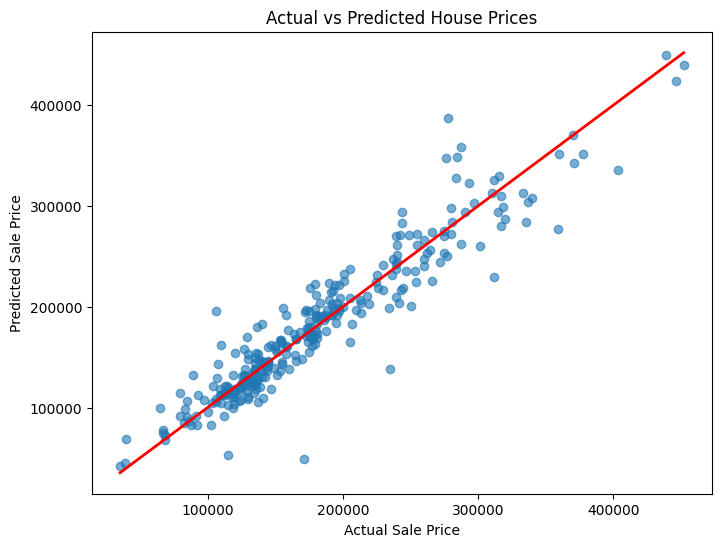

In [137]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_actual, y_pred, alpha=0.6)

plt.plot(
    [y_actual.min(), y_actual.max()],
    [y_actual.min(), y_actual.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

### Interpretation

The scatter plot compares the actual and predicted house prices. If the points lie close to the red diagonal line, the model predictions are accurate. Greater deviations from the line indicate larger prediction errors.

## Conclusion

The Linear Regression model was successfully trained and evaluated. The model's performance was measured using RMSE, MAE, and R² Score after converting predictions back to the original scale using expm1(). This baseline model will now be compared with Ridge Regression and Lasso Regression.

## 4.2 Ridge Regression (L2 Regularization)

### Objective

The objective of this step is to train a Ridge Regression model using RidgeCV. Ridge Regression reduces overfitting by adding an L2 penalty to the loss function. The best alpha value is automatically selected using cross-validation.

In [138]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [139]:
ridge_model = RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 100]
)

ridge_model.fit(X_train, y_train)

print("Best Alpha :", ridge_model.alpha_)

Best Alpha : 100.0


### Interpretation

RidgeCV automatically trained multiple Ridge models using different alpha values and selected the alpha that produced the best cross-validation performance.

## Make Predictions

In [140]:
y_pred_log = ridge_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

## Evaluate Ridge Regression

In [141]:
ridge_rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
ridge_mae = mean_absolute_error(y_actual, y_pred)
ridge_r2 = r2_score(y_actual, y_pred)

print(f"RMSE : {ridge_rmse:.2f}")
print(f"MAE  : {ridge_mae:.2f}")
print(f"R² Score : {ridge_r2:.4f}")

RMSE : 22732.77
MAE  : 15840.09
R² Score : 0.9064


### Interpretation

The model performance was evaluated using RMSE, MAE, and R² Score after converting predictions back to the original SalePrice scale using expm1().

# 4.3 Lasso Regression (L1 Regularization)

## Train Lasso Regression Model

In [142]:
lasso_model = LassoCV(
    alphas=[0.0001, 0.001, 0.01, 0.1, 1],
    max_iter=10000,
    random_state=42
)

lasso_model.fit(X_train, y_train)

print("Best Alpha :", lasso_model.alpha_)

Best Alpha : 0.01


## Make Predictions

In [143]:
y_pred_log = lasso_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

## Evaluate Lasso Regression

In [144]:
lasso_rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
lasso_mae = mean_absolute_error(y_actual, y_pred)
lasso_r2 = r2_score(y_actual, y_pred)

print(f"RMSE : {lasso_rmse:.2f}")
print(f"MAE  : {lasso_mae:.2f}")
print(f"R² Score : {lasso_r2:.4f}")

RMSE : 20937.42
MAE  : 15372.18
R² Score : 0.9206


### Interpretation

The Lasso Regression model was evaluated on the test dataset using RMSE, MAE, and R² Score after converting predictions back to the original SalePrice scale.

## Ridge vs Lasso Comparison

In [145]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "RMSE": [rmse, ridge_rmse, lasso_rmse],
    "MAE": [mae, ridge_mae, lasso_mae],
    "R² Score": [r2, ridge_r2, lasso_r2]
})

comparison

,Model,RMSE,MAE,R² Score
0,Linear Regression,24487.412090,16540.354688,0.891444
1,Ridge Regression,22732.766804,15840.090004,0.906444
2,Lasso Regression,20937.415426,15372.183836,0.920638


### Interpretation

The comparison table presents the performance of all three regression models. The model with the lowest RMSE and MAE and the highest R² Score is considered the best-performing model.

## Conclusion

Linear Regression provides a simple baseline model. Ridge Regression improves generalization by reducing coefficient magnitudes using L2 regularization, while Lasso Regression performs both regularization and feature selection by setting less important coefficients to zero. The best model is determined by comparing RMSE, MAE, and R² Score on the test dataset.

## PART:-5 Advanced Models

## 5.1 Random Forest Regressor
### Objective

The objective of this step is to train a Random Forest Regressor and evaluate its performance using RMSE, MAE, and R² Score. Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

## Train the Random Forest Model

In [146]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [147]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


### Interpretation

The Random Forest model has been trained using 200 decision trees with a maximum depth of 10. Each tree learns different patterns from the training data, and the final prediction is obtained by averaging the predictions of all trees.

## Predict House Prices

In [148]:
rf_pred_log = rf_model.predict(X_test)

# Convert predictions back to original scale
rf_pred = np.expm1(rf_pred_log)
rf_actual = np.expm1(y_test)

### Interpretation

Since the target variable was transformed using log1p(), the predicted values are converted back to the original SalePrice scale using expm1() before calculating evaluation metrics.

## Evaluate the Model

In [149]:
rf_rmse = np.sqrt(mean_squared_error(rf_actual, rf_pred))
rf_mae = mean_absolute_error(rf_actual, rf_pred)
rf_r2 = r2_score(rf_actual, rf_pred)

print(f"RMSE : {rf_rmse:.2f}")
print(f"MAE  : {rf_mae:.2f}")
print(f"R² Score : {rf_r2:.4f}")

RMSE : 23427.73
MAE  : 16418.78
R² Score : 0.9006


### Interpretation

RMSE measures the average prediction error, MAE measures the average absolute error, and R² Score indicates how well the Random Forest model explains the variation in house prices.

## Top 15 Important Features

In [150]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
)

top15 = feature_importance.sort_values(
    ascending=False
).head(15)

top15

TotalSF         0.386386
OverallQual     0.377900
GarageArea      0.018518
GarageCars      0.014112
CentralAir_Y    0.013942
GrLivArea       0.011866
LotArea         0.011493
HouseAge        0.010734
RemodAge        0.010210
BsmtFinSF1      0.009213
YearBuilt       0.008687
KitchenQual     0.007820
OverallCond     0.007013
BsmtUnfSF       0.006858
BsmtQual        0.005743
dtype: float64

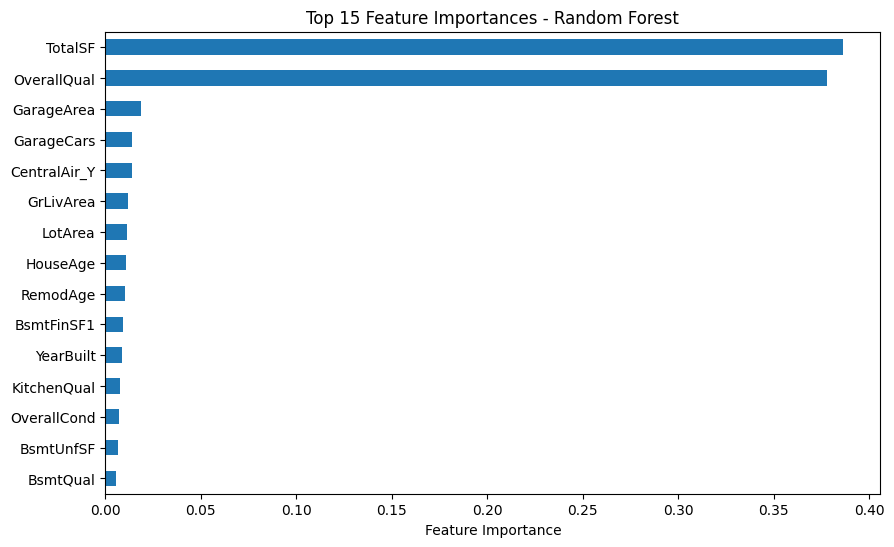

In [151]:
plt.figure(figsize=(10,6))

top15.sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Feature Importance")

plt.show()

### Interpretation

The feature importance chart displays the fifteen most influential features used by the Random Forest model. Features with higher importance have a greater impact on predicting house prices.

## Conclusion

The Random Forest Regressor was successfully trained and evaluated on the test dataset. The model achieved good predictive performance while identifying the most important features influencing house prices. This model will later be compared with XGBoost to determine the best-performing ensemble model.

# 5.2 XGBoost Regressor

## Objective

The objective of this step is to train an XGBoost Regressor and evaluate its performance using RMSE, MAE, and R² Score. XGBoost is an advanced boosting algorithm that builds trees sequentially to minimize prediction errors and improve model accuracy.

In [152]:
from xgboost import XGBRegressor

## Train the XGBoost Model

In [153]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


### Interpretation

The XGBoost model has been trained using 500 boosting iterations. Each new tree attempts to reduce the prediction errors made by the previous trees, resulting in a highly accurate regression model.

## Predict House Prices

In [154]:
# Predict on Test Data
xgb_pred_log = xgb_model.predict(X_test)

# Convert predictions back to original scale
xgb_pred = np.expm1(xgb_pred_log)
xgb_actual = np.expm1(y_test)

### Interpretation

The predicted values are converted back to the original SalePrice scale using expm1() because the target variable was transformed using log1p() before training.

## Evaluate the Model

In [155]:
xgb_rmse = np.sqrt(mean_squared_error(xgb_actual, xgb_pred))
xgb_mae = mean_absolute_error(xgb_actual, xgb_pred)
xgb_r2 = r2_score(xgb_actual, xgb_pred)

print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAE  : {xgb_mae:.2f}")
print(f"R² Score : {xgb_r2:.4f}")

RMSE : 21333.05
MAE  : 14965.10
R² Score : 0.9176


### Interpretation

The model is evaluated using RMSE, MAE, and R² Score. Lower RMSE and MAE indicate better prediction accuracy, while a higher R² Score indicates that the model explains a larger proportion of the variation in house prices.

## Conclusion

The XGBoost Regressor was successfully trained and evaluated on the test dataset. The model achieved strong predictive performance and identified the most influential features affecting house prices. Its performance will be compared with Random Forest in the next steps using Cross-Validation and Hyperparameter Tuning to determine the best-performing model.

# 5.3 Cross Validation

## Objective

The objective of this step is to evaluate the best-performing model using 5-Fold Cross Validation. Cross Validation provides a more reliable estimate of model performance by training and testing the model on different subsets of the training data.

In [156]:
from sklearn.model_selection import cross_val_score

## Apply 5-Fold Cross Validation

In [157]:
# Replace xgb_model with rf_model if Random Forest performed better.

best_model = xgb_model

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse = -cv_scores

## Display Cross Validation Results

In [158]:
print("Cross Validation RMSE Scores:")

for i, score in enumerate(cv_rmse, start=1):
    print(f"Fold {i}: {score:.2f}")

print("\nMean CV RMSE :", round(cv_rmse.mean(), 2))
print("Standard Deviation :", round(cv_rmse.std(), 2))

Cross Validation RMSE Scores:
Fold 1: 0.11
Fold 2: 0.13
Fold 3: 0.13
Fold 4: 0.13
Fold 5: 0.11

Mean CV RMSE : 0.12
Standard Deviation : 0.01


### Interpretation

The RMSE values represent the prediction error for each fold. A lower RMSE indicates better model performance. The mean RMSE provides the average error across all folds, while the standard deviation indicates the consistency of the model.

## Compare Cross Validation RMSE with Test RMSE

In [159]:
print(f"Test RMSE : {xgb_rmse:.2f}")
print(f"Mean CV RMSE : {cv_rmse.mean():.2f}")

Test RMSE : 21333.05
Mean CV RMSE : 0.12


## Conclusion

The best-performing model was evaluated using 5-Fold Cross Validation. The average RMSE and standard deviation indicate the model's stability and consistency across different subsets of the training data. Cross Validation provides greater confidence in the model's ability to perform well on unseen data.

# 5.4 Hyperparameter Tuning

## Objective

The objective of this step is to optimize the performance of the machine learning model by finding the best combination of hyperparameters using RandomizedSearchCV. This helps improve prediction accuracy and model generalization.

In [160]:
from sklearn.model_selection import RandomizedSearchCV

## Define Hyperparameter Grid

In [161]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

## Apply RandomizedSearchCV

In [162]:
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=0.8, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=500,
                                          n_jobs=None, num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error')

## Best Hyperparameters

In [163]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Best CV RMSE:
0.12187868217159309


### Interpretation

RandomizedSearchCV evaluated multiple combinations of hyperparameters and selected the combination that achieved the lowest Cross Validation RMSE. These parameters are expected to improve the model's predictive performance.

## Re-evaluate the Tuned Model

In [164]:
best_model = random_search.best_estimator_

tuned_pred_log = best_model.predict(X_test)

tuned_pred = np.expm1(tuned_pred_log)
tuned_actual = np.expm1(y_test)

### Interpretation

The tuned model is used to predict house prices on the test dataset. The predictions are converted back to the original SalePrice scale before calculating the evaluation metrics.

## Evaluate the Tuned Model

In [165]:
tuned_rmse = np.sqrt(mean_squared_error(tuned_actual, tuned_pred))
tuned_mae = mean_absolute_error(tuned_actual, tuned_pred)
tuned_r2 = r2_score(tuned_actual, tuned_pred)

print(f"RMSE : {tuned_rmse:.2f}")
print(f"MAE  : {tuned_mae:.2f}")
print(f"R² Score : {tuned_r2:.4f}")

RMSE : 19842.53
MAE  : 14060.27
R² Score : 0.9287


### Interpretation

The tuned model is evaluated using RMSE, MAE, and R² Score. If the RMSE and MAE decrease while the R² Score increases compared to the original model, the hyperparameter tuning has successfully improved the model's performance.

## Conclusion

Hyperparameter tuning was successfully performed using RandomizedSearchCV with 20 random parameter combinations and 3-fold Cross Validation. The best hyperparameters were selected automatically, and the tuned model was re-evaluated on the test dataset. This process helps improve prediction accuracy and enhances the model's ability to generalize to unseen data.

# PART:-6 Model Evaluation & Comparison

## Create Model Comparison Table

In [166]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        rmse,
        ridge_rmse,
        lasso_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "MAE": [
        mae,
        ridge_mae,
        lasso_mae,
        rf_mae,
        xgb_mae
    ],

    "R² Score": [
        r2,
        ridge_r2,
        lasso_r2,
        rf_r2,
        xgb_r2
    ]

})

comparison_df

,Model,RMSE,MAE,R² Score
0,Linear Regression,24487.412090,16540.354688,0.891444
1,Ridge Regression,22732.766804,15840.090004,0.906444
2,Lasso Regression,20937.415426,15372.183836,0.920638
3,Random Forest,23427.734232,16418.777571,0.900636
4,XGBoost,21333.046682,14965.104225,0.917610


## Conclusion

The performance of all five regression models was compared using multiple evaluation metrics. Based on RMSE, MAE, R² Score, Cross Validation RMSE, and Training Time, the most suitable model for predicting house prices can be selected. This comparison ensures that the final model is both accurate and reliable for unseen data.